**XGBoost: Temperature Post-Processing for Vlinder91**

TAI Project 2 — Simon De Kock

Input:  Pre-cleaned train/val/test CSVs with ensemble-derived features
Target: obs_temp_K (observed 2m temperature in Kelvin)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from scipy.stats import randint, uniform, loguniform


random_state = 42
random.seed(random_state)
np.random.seed(random_state)

In [5]:
train = pd.read_csv('processed_data/train.csv', parse_dates=['model_time', 'valid_time'])
val   = pd.read_csv('processed_data/val.csv',   parse_dates=['model_time', 'valid_time'])
test  = pd.read_csv('processed_data/test.csv',  parse_dates=['model_time', 'valid_time'])

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')


Train: 1100 | Val: 367 | Test: 367


In [6]:
# Drop non-feature columns and the Celsius duplicate of the target
DROP_COLS = ['model_time', 'valid_time', 'obs_temp_C']
TARGET    = 'obs_temp_K'

FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS + [TARGET]]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

print(f'Number of features: {len(FEATURE_COLS)}')

Number of features: 103


In [7]:
# Predict the mean of the training target — gives a lower-bound reference score.
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)

y_val_base = baseline.predict(X_val)
print('\n--- Baseline (mean predictor) ---')
print(f'Val RMSE : {np.sqrt(mean_squared_error(y_val, y_val_base)):.4f} K')
print(f'Val MAE  : {mean_absolute_error(y_val, y_val_base):.4f} K')
print(f'Val R²   : {r2_score(y_val, y_val_base):.4f}')



--- Baseline (mean predictor) ---
Val RMSE : 4.9776 K
Val MAE  : 3.8088 K
Val R²   : -0.0614


In [8]:

xgb_pipe = Pipeline([
    ('scaler',   StandardScaler()),
    ('selector', SelectKBest(score_func=mutual_info_regression, k=20)),  # tune k
    ('reg',      XGBRegressor(
                     objective='reg:squarederror',
                     random_state=random_state,
                     n_jobs=-1
                 ))
])

# Hyperparameter search space
param_dist_xgb = {
    'selector__k':          [10, 15, 20, 30, 'all'],
    'reg__n_estimators':    randint(100, 500),
    'reg__max_depth':       randint(3, 9),
    'reg__learning_rate':   loguniform(0.01, 0.3),   # log-uniform: spans orders of magnitude
    'reg__subsample':       uniform(0.5, 0.5),        # uniform between 0.5 and 1.0
    'reg__colsample_bytree':uniform(0.5, 0.5),
    'reg__min_child_weight':randint(1, 10),
    'reg__reg_alpha':       loguniform(1e-4, 1.0),    # L1 regularisation
    'reg__reg_lambda':      loguniform(1e-4, 1.0),    # L2 regularisation
}

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=random_state,
    n_jobs=-1,
    verbose=1
)

print('\nFitting XGBoost RandomizedSearchCV...')
xgb_search.fit(X_train, y_train)

print(f'Best CV RMSE : {-xgb_search.best_score_:.4f} K')
print(f'Best params  : {xgb_search.best_params_}')



Fitting XGBoost RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV RMSE : 2.2679 K
Best params  : {'reg__colsample_bytree': np.float64(0.8171756723506819), 'reg__learning_rate': np.float64(0.10127085828319964), 'reg__max_depth': 7, 'reg__min_child_weight': 6, 'reg__n_estimators': 346, 'reg__reg_alpha': np.float64(0.04881375191603671), 'reg__reg_lambda': np.float64(0.11129571947046), 'reg__subsample': np.float64(0.6188187719961998), 'selector__k': 'all'}


In [9]:
best_xgb = xgb_search.best_estimator_
y_val_pred = best_xgb.predict(X_val)

print('\n--- XGBoost Validation ---')
print(f'Val RMSE : {np.sqrt(mean_squared_error(y_val, y_val_pred)):.4f} K')
print(f'Val MAE  : {mean_absolute_error(y_val, y_val_pred):.4f} K')
print(f'Val R²   : {r2_score(y_val, y_val_pred):.4f}')



--- XGBoost Validation ---
Val RMSE : 1.7198 K
Val MAE  : 1.3608 K
Val R²   : 0.8733


In [10]:
y_test_pred = best_xgb.predict(X_test)

print('\n--- XGBoost Test ---')
print(f'Test RMSE : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f} K')
print(f'Test MAE  : {mean_absolute_error(y_test, y_test_pred):.4f} K')
print(f'Test R²   : {r2_score(y_test, y_test_pred):.4f}')



--- XGBoost Test ---
Test RMSE : 2.5225 K
Test MAE  : 1.8448 K
Test R²   : 0.8134


In [14]:
# Stronger baseline: raw NWP forecast without any correction
y_test_nwp = X_test['t2m_mean']

rmse = np.sqrt(mean_squared_error(y_test, y_test_nwp))
mae  = mean_absolute_error(y_test, y_test_nwp)
r2   = r2_score(y_test, y_test_nwp)
print(f'NWP raw     RMSE={rmse:.4f} K  MAE={mae:.4f} K  R²={r2:.4f}')

NWP raw     RMSE=2.9030 K  MAE=2.2086 K  R²=0.7528


So the model did in fact improve the accuracy of the forecast by like 0.4K :P


In [18]:
# Baseline on test set
y_test_base = baseline.predict(X_test)

print('\n--- Model Comparison (Test Set) ---')
models = {
    'Baseline':  y_test_base,
    'XGBoost':   y_test_pred,
}

for name, preds in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    print(f'{name:10s}  RMSE={rmse:.4f} K  MAE={mae:.4f} K  R²={r2:.4f}')


--- Model Comparison (Test Set) ---
Baseline    RMSE=8.1024 K  MAE=6.3896 K  R²=-0.9256
XGBoost     RMSE=2.5225 K  MAE=1.8448 K  R²=0.8134



Top 15 features by XGBoost importance:
   1. t2m_mean                            0.4464
   2. t2m_q10                             0.1684
   3. skt_q10                             0.0795
   4. skt_mean                            0.0667
   5. hour_sin                            0.0295
   6. doy_cos                             0.0269
   7. skt_q90                             0.0154
   8. day_of_year                         0.0119
   9. st_q90                              0.0084
  10. d2m_mean                            0.0084
  11. t2m_q90                             0.0075
  12. sm_q10                              0.0061
  13. d2m_q90                             0.0056
  14. tcw_mean                            0.0048
  15. d2m_q10                             0.0047


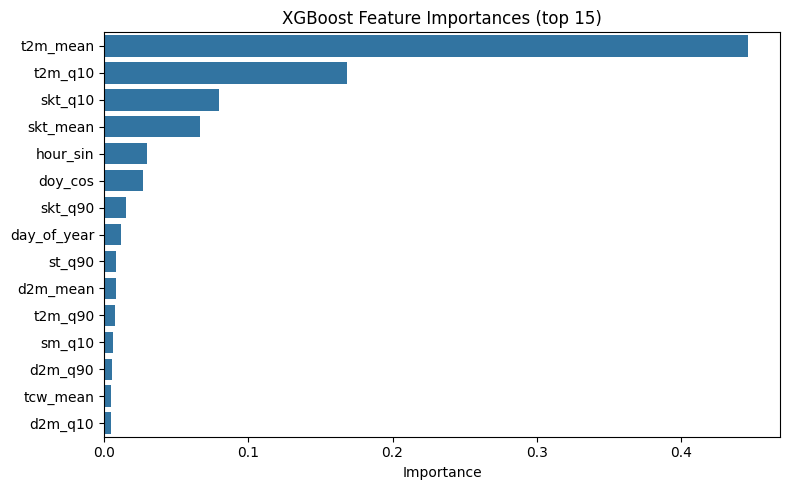

In [ ]:
# Retrieve selected feature names after the selector step
selector      = best_xgb.named_steps['selector']
selected_mask = selector.get_support()
selected_features = np.array(FEATURE_COLS)[selected_mask]

importances = best_xgb.named_steps['reg'].feature_importances_
indices     = np.argsort(importances)[::-1]

print('\nTop 15 features by XGBoost importance:')
for i in range(min(15, len(selected_features))):
    print(f'  {i+1:2d}. {selected_features[indices[i]]:35s} {importances[indices[i]]:.4f}')

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices[:15]], y=selected_features[indices[:15]])
plt.title('XGBoost Feature Importances (top 15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

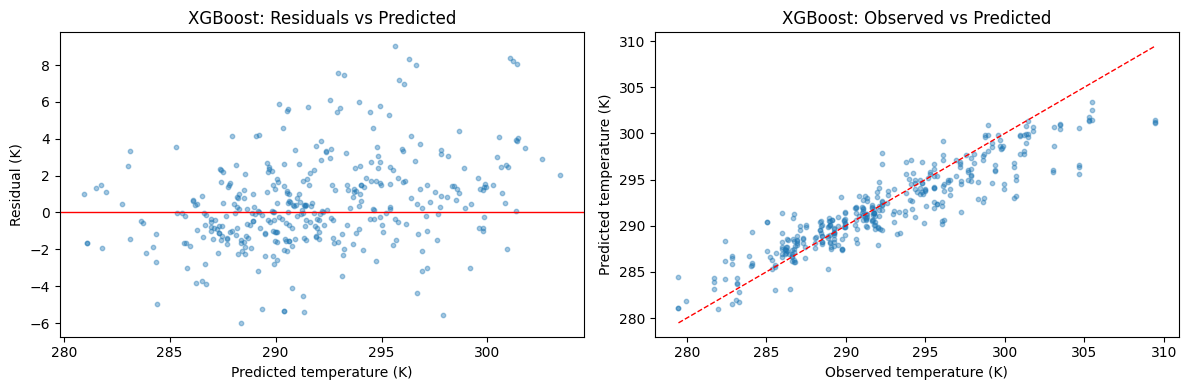

In [19]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test_pred, residuals, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Predicted temperature (K)')
axes[0].set_ylabel('Residual (K)')
axes[0].set_title('XGBoost: Residuals vs Predicted')

axes[1].scatter(y_test, y_test_pred, alpha=0.4, s=10)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1)
axes[1].set_xlabel('Observed temperature (K)')
axes[1].set_ylabel('Predicted temperature (K)')
axes[1].set_title('XGBoost: Observed vs Predicted')

plt.tight_layout()
plt.show()


In [20]:
import joblib
joblib.dump(best_xgb, 'models/XGBoost/xgb_best_model.pkl')
print('\nModel saved to xgb_best_model.pkl')


Model saved to xgb_best_model.pkl
